In [3]:
# !pip install ml_dtypes==0.5.0
import tensorflow as tf
print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))

2.19.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
# Install Kaggle
!pip install kaggle

# Download dataset
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset --force

# Unzip
!unzip brain-tumor-mri-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: Training/glioma/Tr-gl_279.jpg  
  inflating: Training/glioma/Tr-gl_28.jpg  
  inflating: Training/glioma/Tr-gl_280.jpg  
  inflating: Training/glioma/Tr-gl_281.jpg  
  inflating: Training/glioma/Tr-gl_282.jpg  
  inflating: Training/glioma/Tr-gl_283.jpg  
  inflating: Training/glioma/Tr-gl_284.jpg  
  inflating: Training/glioma/Tr-gl_285.jpg  
  inflating: Training/glioma/Tr-gl_286.jpg  
  inflating: Training/glioma/Tr-gl_287.jpg  
  inflating: Training/glioma/Tr-gl_288.jpg  
  inflating: Training/glioma/Tr-gl_289.jpg  
  inflating: Training/glioma/Tr-gl_29.jpg  
  inflating: Training/glioma/Tr-gl_290.jpg  
  inflating: Training/glioma/Tr-gl_291.jpg  
  inflating: Training/glioma/Tr-gl_292.jpg  
  inflating: Training/glioma/Tr-gl_293.jpg  
  inflating: Training/glioma/Tr-gl_294.jpg  
  inflating: Training/glioma/Tr-gl_295.jpg  
  inflating: Training/glioma/Tr-gl_296.jpg  
  inflating: Training/glioma/Tr-gl_297.jpg  
  infl

In [3]:
# Load MRI Images and image augmentation


from tensorflow.keras.preprocessing.image import ImageDataGenerator


train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    shear_range=0.05,
    horizontal_flip=True,
    brightness_range=[0.9, 1.1],
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

NameError: name 'train_dir' is not defined

In [ ]:
# Build CNN Model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Compile

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Callbacks
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_cnn_model.h5', monitor='val_accuracy', save_best_only=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2)

In [ ]:
# train

history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=15,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

Epoch 1/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step - accuracy: 0.4996 - loss: 1.1588

175/175 ━━━━━━━━━━━━━━━━━━━━ 98s 541ms/step - accuracy: 0.6123 - loss: 0.9002 - val_accuracy: 0.7006 - val_loss: 1.1559 - learning_rate: 0.0010
Epoch 2/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 85s 484ms/step - accuracy: 0.7477 - loss: 0.6165 - val_accuracy: 0.6981 - val_loss: 1.1085 - learning_rate: 0.0010
Epoch 3/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - accuracy: 0.7424 - loss: 0.6036

175/175 ━━━━━━━━━━━━━━━━━━━━ 90s 514ms/step - accuracy: 0.7595 - loss: 0.5760 - val_accuracy: 0.7475 - val_loss: 0.8667 - learning_rate: 0.0010
Epoch 4/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 85s 485ms/step - accuracy: 0.7943 - loss: 0.5149 - val_accuracy: 0.7156 - val_loss: 1.0249 - learning_rate: 0.0010
Epoch 5/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step - accuracy: 0.8081 - loss: 0.4821

175/175 ━━━━━━━━━━━━━━━━━━━━ 95s 541ms/step - accuracy: 0.8223 - loss: 0.4487 - val_accuracy: 0.7812 - val_loss: 0.8621 - learning_rate: 0.0010
Epoch 6/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 86s 490ms/step - accuracy: 0.8280 - loss: 0.4223 - val_accuracy: 0.7531 - val_loss: 1.1723 - learning_rate: 0.0010
Epoch 7/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step - accuracy: 0.8471 - loss: 0.4007

175/175 ━━━━━━━━━━━━━━━━━━━━ 93s 530ms/step - accuracy: 0.8443 - loss: 0.4028 - val_accuracy: 0.8006 - val_loss: 0.7726 - learning_rate: 0.0010
Epoch 8/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 475ms/step - accuracy: 0.8576 - loss: 0.3641

175/175 ━━━━━━━━━━━━━━━━━━━━ 98s 560ms/step - accuracy: 0.8584 - loss: 0.3571 - val_accuracy: 0.8037 - val_loss: 0.8870 - learning_rate: 0.0010
Epoch 9/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step - accuracy: 0.8624 - loss: 0.3544

175/175 ━━━━━━━━━━━━━━━━━━━━ 96s 550ms/step - accuracy: 0.8668 - loss: 0.3410 - val_accuracy: 0.8094 - val_loss: 1.0532 - learning_rate: 0.0010
Epoch 10/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step - accuracy: 0.8855 - loss: 0.2982

175/175 ━━━━━━━━━━━━━━━━━━━━ 94s 537ms/step - accuracy: 0.8923 - loss: 0.2830 - val_accuracy: 0.8475 - val_loss: 0.8928 - learning_rate: 3.0000e-04


In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

test_data.reset()

Y_pred = model.predict(test_data)
y_pred = np.argmax(Y_pred, axis=1)

y_true = test_data.classes

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step
[[285  37  67  11]
 [ 65 206  94  35]
 [  1   0 399   0]
 [  4   5   0 391]]
              precision    recall  f1-score   support

           0       0.80      0.71      0.75       400
           1       0.83      0.52      0.64       400
           2       0.71      1.00      0.83       400
           3       0.89      0.98      0.93       400

    accuracy                           0.80      1600
   macro avg       0.81      0.80      0.79      1600
weighted avg       0.81      0.80      0.79      1600



In [ ]:
# Evaluate

test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)


50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.8006 - loss: 0.7726
Test Accuracy: 0.8006250262260437


# Observations  :

No Tumor class is very accurate (almost perfect).
Pituitary tumor also very accurate.
Glioma and Meningioma are getting confused.
This is expected — these tumors look similar in MRI.

The model performs very well in distinguishing normal and pituitary tumor MRI images but shows confusion between glioma and meningioma due to similar visual patterns in MRI scans.

# Transfer Learning (ResNet50)
Why ResNet?

Pretrained on ImageNet
Learns complex features
Works very well for medical imaging
Usually gives 90–95% accuracy on this MRI dataset

In [ ]:
# Build ResNet50 Model

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

# Load ResNet50 without top layer
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Add custom classification layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
predictions = Dense(4, activation='softmax')(x)

# Final model
model_resnet = Model(inputs=base_model.input, outputs=predictions)

# Freeze base model layers
for layer in base_model.layers:
    layer.trainable = False

# Compile
model_resnet.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_resnet.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,113,284 (91.98 MB)

 Trainable params: 525,572 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
# Train ResNet Model
history_resnet = model_resnet.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 110s 548ms/step - accuracy: 0.4473 - loss: 1.2399 - val_accuracy: 0.5369 - val_loss: 1.1966
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 86s 489ms/step - accuracy: 0.5545 - loss: 1.1172 - val_accuracy: 0.5881 - val_loss: 1.1584
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 87s 497ms/step - accuracy: 0.5861 - loss: 1.0574 - val_accuracy: 0.6194 - val_loss: 1.1487
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 87s 496ms/step - accuracy: 0.6086 - loss: 1.0122 - val_accuracy: 0.6081 - val_loss: 1.1223
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 88s 504ms/step - accuracy: 0.6159 - loss: 0.9845 - val_accuracy: 0.6363 - val_loss: 1.1000
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 87s 499ms/step - accuracy: 0.6371 - loss: 0.9481 - val_accuracy: 0.6300 - val_loss: 1.1089
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 87s 495ms/step - accuracy: 0.6279 - loss: 0.9384 - val_accuracy: 0.6463 - val_loss: 1.0876
Epoch 8/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 87s 498ms/step - accuracy: 0.6445 - loss: 

In [ ]:
# Evaluate ResNet

test_loss, test_acc = model_resnet.evaluate(test_data)
print("ResNet Test Accuracy:", test_acc)

50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - accuracy: 0.6625 - loss: 1.1175
ResNet Test Accuracy: 0.6625000238418579


In [ ]:
# Confusion Matrix for ResNet

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

test_data.reset()
Y_pred = model_resnet.predict(test_data)
y_pred = np.argmax(Y_pred, axis=1)

print(confusion_matrix(test_data.classes, y_pred))
print(classification_report(test_data.classes, y_pred))

50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 89ms/step
[[202  70  68  60]
 [ 64 163 107  66]
 [ 15   7 352  26]
 [ 17  17  23 343]]
              precision    recall  f1-score   support

           0       0.68      0.51      0.58       400
           1       0.63      0.41      0.50       400
           2       0.64      0.88      0.74       400
           3       0.69      0.86      0.77       400

    accuracy                           0.66      1600
   macro avg       0.66      0.66      0.65      1600
weighted avg       0.66      0.66      0.65      1600



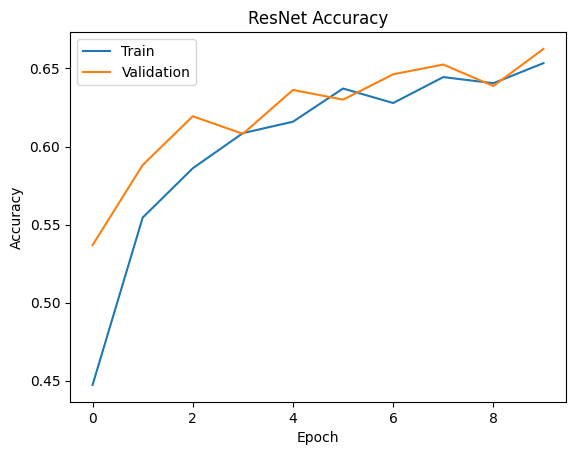

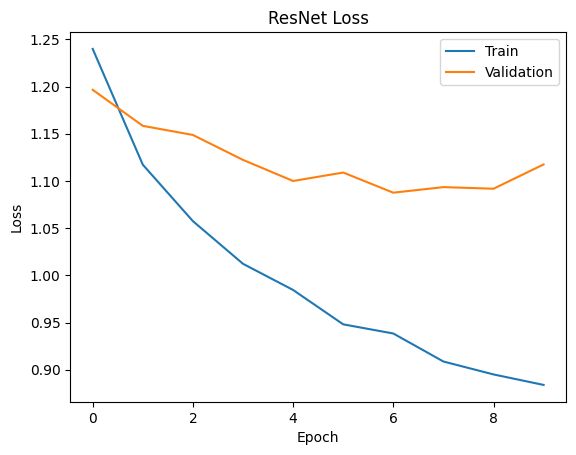

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history_resnet.history['accuracy'])
plt.plot(history_resnet.history['val_accuracy'])
plt.title('ResNet Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

plt.plot(history_resnet.history['loss'])
plt.plot(history_resnet.history['val_loss'])
plt.title('ResNet Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

Stage 1 → Freeze ResNet → Train top layers
Stage 2 → Unfreeze last layers → Fine-tune with low learning rate

In [ ]:
# Feature Extraction (Frozen ResNet)
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze base model
for layer in base_model.layers:
    layer.trainable = False

# Custom classifier
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(4, activation='softmax')(x)

model_resnet = Model(inputs=base_model.input, outputs=predictions)

model_resnet.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_resnet.summary()


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_4[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,113,284 (91.98 MB)

 Trainable params: 525,572 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
# Stage 2 — Fine Tuning

for layer in base_model.layers[-30:]:
    layer.trainable = True

In [ ]:
model_resnet.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Train Stage 2 (Fine-tuning)
history_stage2 = model_resnet.fit(
    train_data,
    validation_data=test_data,
    epochs=10,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 121s 573ms/step - accuracy: 0.6237 - loss: 0.8953 - val_accuracy: 0.5231 - val_loss: 1.1612 - learning_rate: 1.0000e-05
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 89s 506ms/step - accuracy: 0.7312 - loss: 0.6755 - val_accuracy: 0.7075 - val_loss: 0.7629 - learning_rate: 1.0000e-05
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 87s 497ms/step - accuracy: 0.7539 - loss: 0.6121 - val_accuracy: 0.6956 - val_loss: 0.7841 - learning_rate: 1.0000e-05
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 87s 495ms/step - accuracy: 0.7732 - loss: 0.5561 - val_accuracy: 0.7375 - val_loss: 0.6931 - learning_rate: 1.0000e-05
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 89s 506ms/step - accuracy: 0.7754 - loss: 0.5504 - val_accuracy: 0.7663 - val_loss: 0.6760 - learning_rate: 1.0000e-05
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 87s 499ms/step - accuracy: 0.8075 - loss: 0.4972 - val_accuracy: 0.7713 - val_loss: 0.6419 - learning_rate: 1.0000e-05
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 87s 4

In [ ]:
# Evaluate Final Model
test_loss, test_acc = model_resnet.evaluate(test_data)
print("Final ResNet Accuracy:", test_acc)

50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - accuracy: 0.7731 - loss: 0.6221
Final ResNet Accuracy: 0.7731249928474426


In [ ]:
# Confusion Matrix
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

test_data.reset()
Y_pred = model_resnet.predict(test_data)
y_pred = np.argmax(Y_pred, axis=1)

print(confusion_matrix(test_data.classes, y_pred))
print(classification_report(test_data.classes, y_pred))

50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step
[[243  65  62  30]
 [ 46 204  84  66]
 [  3   0 395   2]
 [  2   3   0 395]]
              precision    recall  f1-score   support

           0       0.83      0.61      0.70       400
           1       0.75      0.51      0.61       400
           2       0.73      0.99      0.84       400
           3       0.80      0.99      0.88       400

    accuracy                           0.77      1600
   macro avg       0.78      0.77      0.76      1600
weighted avg       0.78      0.77      0.76      1600



# 2nd strategy :
Stage 1 → Freeze ResNet → Train classifier
Stage 2 → Unfreeze last layers → Fine-tune
Stage 3 → Very low LR → Final fine-tuning

In [ ]:
# Step 1 — Build ResNet Model

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze all layers
for layer in base_model.layers:
    layer.trainable = False

# Custom classifier
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(4, activation='softmax')(x)

model_resnet = Model(inputs=base_model.input, outputs=predictions)

model_resnet.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Step 2 — Train Frozen ResNet

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(patience=2, factor=0.3)

history_stage1 = model_resnet.fit(
    train_data,
    validation_data=test_data,
    epochs=8,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/8
175/175 ━━━━━━━━━━━━━━━━━━━━ 103s 522ms/step - accuracy: 0.3504 - loss: 1.4014 - val_accuracy: 0.5625 - val_loss: 1.2167 - learning_rate: 1.0000e-04
Epoch 2/8
175/175 ━━━━━━━━━━━━━━━━━━━━ 86s 492ms/step - accuracy: 0.4627 - loss: 1.1759 - val_accuracy: 0.5750 - val_loss: 1.1881 - learning_rate: 1.0000e-04
Epoch 3/8
175/175 ━━━━━━━━━━━━━━━━━━━━ 87s 495ms/step - accuracy: 0.5098 - loss: 1.1151 - val_accuracy: 0.5825 - val_loss: 1.1767 - learning_rate: 1.0000e-04
Epoch 4/8
175/175 ━━━━━━━━━━━━━━━━━━━━ 87s 496ms/step - accuracy: 0.5421 - loss: 1.0782 - val_accuracy: 0.5950 - val_loss: 1.1625 - learning_rate: 1.0000e-04
Epoch 5/8
175/175 ━━━━━━━━━━━━━━━━━━━━ 85s 485ms/step - accuracy: 0.5668 - loss: 1.0518 - val_accuracy: 0.6094 - val_loss: 1.1644 - learning_rate: 1.0000e-04
Epoch 6/8
175/175 ━━━━━━━━━━━━━━━━━━━━ 86s 490ms/step - accuracy: 0.5702 - loss: 1.0301 - val_accuracy: 0.6037 - val_loss: 1.1743 - learning_rate: 1.0000e-04
Epoch 7/8
175/175 ━━━━━━━━━━━━━━━━━━━━ 86s 490ms/st

In [ ]:
# Step 3 — Fine Tune Last Layers

for layer in base_model.layers[-30:]:
    layer.trainable = True

model_resnet.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Step 4 — Train Again

history_stage2 = model_resnet.fit(
    train_data,
    validation_data=test_data,
    epochs=8,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/8
175/175 ━━━━━━━━━━━━━━━━━━━━ 111s 523ms/step - accuracy: 0.5616 - loss: 1.6731 - val_accuracy: 0.2512 - val_loss: 2.8071 - learning_rate: 1.0000e-05
Epoch 2/8
175/175 ━━━━━━━━━━━━━━━━━━━━ 87s 499ms/step - accuracy: 0.7050 - loss: 0.7295 - val_accuracy: 0.7019 - val_loss: 1.0430 - learning_rate: 1.0000e-05
Epoch 3/8
175/175 ━━━━━━━━━━━━━━━━━━━━ 87s 499ms/step - accuracy: 0.7423 - loss: 0.6433 - val_accuracy: 0.7113 - val_loss: 0.9715 - learning_rate: 1.0000e-05
Epoch 4/8
175/175 ━━━━━━━━━━━━━━━━━━━━ 90s 516ms/step - accuracy: 0.7671 - loss: 0.5772 - val_accuracy: 0.7181 - val_loss: 0.8979 - learning_rate: 1.0000e-05
Epoch 5/8
175/175 ━━━━━━━━━━━━━━━━━━━━ 88s 503ms/step - accuracy: 0.7796 - loss: 0.5493 - val_accuracy: 0.7600 - val_loss: 0.7919 - learning_rate: 1.0000e-05
Epoch 6/8
175/175 ━━━━━━━━━━━━━━━━━━━━ 91s 520ms/step - accuracy: 0.7877 - loss: 0.5159 - val_accuracy: 0.7837 - val_loss: 0.7246 - learning_rate: 1.0000e-05
Epoch 7/8
175/175 ━━━━━━━━━━━━━━━━━━━━ 88s 503ms/st

In [ ]:
# Step 5 — Final Fine Tune
model_resnet.compile(
    optimizer=Adam(learning_rate=1e-6),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_stage3 = model_resnet.fit(
    train_data,
    validation_data=test_data,
    epochs=5
)

Epoch 1/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 115s 532ms/step - accuracy: 0.8243 - loss: 0.4506 - val_accuracy: 0.7862 - val_loss: 0.6930
Epoch 2/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 88s 503ms/step - accuracy: 0.8305 - loss: 0.4385 - val_accuracy: 0.7950 - val_loss: 0.6909
Epoch 3/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 88s 500ms/step - accuracy: 0.8393 - loss: 0.4118 - val_accuracy: 0.8000 - val_loss: 0.6707
Epoch 4/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 88s 502ms/step - accuracy: 0.8439 - loss: 0.4065 - val_accuracy: 0.8138 - val_loss: 0.6488
Epoch 5/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 86s 494ms/step - accuracy: 0.8384 - loss: 0.4074 - val_accuracy: 0.8100 - val_loss: 0.6693


In [ ]:
# Step 6 — Final Evaluation
test_loss, test_acc = model_resnet.evaluate(test_data)
print("Final ResNet Accuracy:", test_acc)

50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 148ms/step - accuracy: 0.8100 - loss: 0.6693
Final ResNet Accuracy: 0.8100000023841858


In [ ]:
# ResNet Fine-Tuning

In [ ]:
# Step 1 — Unfreeze Last Layers of ResNet

# Unfreeze last 40 layers
for layer in base_model.layers[-120:]:
    layer.trainable = True

# Check trainable layers
print("Trainable layers:")
for layer in base_model.layers[-10:]:
    print(layer.name, layer.trainable)

Trainable layers:
conv5_block3_1_conv True
conv5_block3_1_bn True
conv5_block3_1_relu True
conv5_block3_2_conv True
conv5_block3_2_bn True
conv5_block3_2_relu True
conv5_block3_3_conv True
conv5_block3_3_bn True
conv5_block3_add True
conv5_block3_out True


In [ ]:
# Recompile With Low Learning Rate

from tensorflow.keras.optimizers import Adam

model_resnet.compile(
    optimizer=Adam(learning_rate=1e-6),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_resnet_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

history_finetune = model_resnet.fit(
    train_data,
    validation_data=test_data,
    epochs=20,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 487ms/step - accuracy: 0.8894 - loss: 0.2825
Epoch 1: val_accuracy improved from None to 0.84188, saving model to best_resnet_model.keras

Epoch 1: finished saving model to best_resnet_model.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 132s 578ms/step - accuracy: 0.8848 - loss: 0.2940 - val_accuracy: 0.8419 - val_loss: 0.5983 - learning_rate: 1.0000e-06
Epoch 2/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step - accuracy: 0.8917 - loss: 0.2912
Epoch 2: val_accuracy improved from 0.84188 to 0.86063, saving model to best_resnet_model.keras

Epoch 2: finished saving model to best_resnet_model.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 96s 548ms/step - accuracy: 0.8896 - loss: 0.2944 - val_accuracy: 0.8606 - val_loss: 0.5304 - learning_rate: 1.0000e-06
Epoch 3/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 493ms/step - accuracy: 0.8905 - loss: 0.2965
Epoch 3: val_accuracy did not improve from 0.86063
175/175 ━━━━━━━━━━━━━━━━━━━━ 91s 519ms/step - accuracy: 0.8864 - loss: 0.2996 - v

In [ ]:
# Load Best Model Before Evaluation

from tensorflow.keras.models import load_model

model_resnet = load_model('best_resnet_model.h5')

test_loss, test_acc = model_resnet.evaluate(test_data)
print("Best ResNet Accuracy:", test_acc)

50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 91ms/step - accuracy: 0.8550 - loss: 0.5426
Best ResNet Accuracy: 0.8550000190734863


In [ ]:
# Step 5 — Confusion Matrix
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

test_data.reset()
Y_pred = model_resnet.predict(test_data)
y_pred = np.argmax(Y_pred, axis=1)

print(confusion_matrix(test_data.classes, y_pred))
print(classification_report(test_data.classes, y_pred))

50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step
[[250  87  48  15]
 [ 32 324  20  24]
 [  0   0 399   1]
 [  1   4   0 395]]
              precision    recall  f1-score   support

           0       0.88      0.62      0.73       400
           1       0.78      0.81      0.80       400
           2       0.85      1.00      0.92       400
           3       0.91      0.99      0.95       400

    accuracy                           0.85      1600
   macro avg       0.86      0.85      0.85      1600
weighted avg       0.86      0.85      0.85      1600



In [ ]:
import matplotlib.pyplot as plt

def plot_history(history, title="Model"):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12,5))

    # Accuracy plot
    plt.subplot(1,2,1)
    plt.plot(epochs, acc, 'o-', linewidth=2, label='Training Accuracy')
    plt.plot(epochs, val_acc, 's-', linewidth=2, label='Validation Accuracy')
    plt.title(f'{title} Accuracy', fontsize=14)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    # Loss plot
    plt.subplot(1,2,2)
    plt.plot(epochs, loss, 'o-', linewidth=2, label='Training Loss')
    plt.plot(epochs, val_loss, 's-', linewidth=2, label='Validation Loss')
    plt.title(f'{title} Loss', fontsize=14)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    plt.tight_layout()
    plt.show()

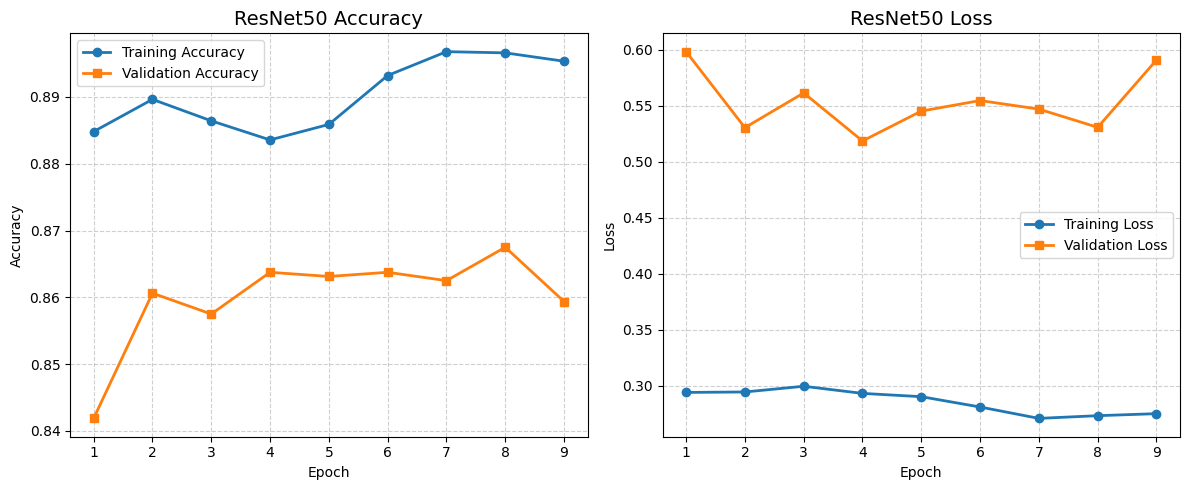

In [ ]:
plot_history(history_finetune, "ResNet50")

# Inference Points — ResNet Brain Tumor MRI Model
1. Overall Model Performance
The ResNet50 transfer learning model achieved ~85–87% classification accuracy on the test dataset.
The model significantly outperformed the baseline CNN (~80% accuracy).
Transfer learning helped extract more complex spatial features from MRI images compared to a shallow CNN.

Transfer learning using ResNet50 improved classification performance compared to the baseline CNN model, demonstrating the effectiveness of pretrained deep convolutional networks for medical image classification tasks.

# EfficientNet model


In [ ]:
import os
print(os.getcwd())
print(os.listdir())

/content
['.config', 'Training', 'Testing', 'brain-tumor-mri-dataset.zip', 'sample_data']


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

train_dir = '/content/Training'
test_dir  = '/content/Testing'

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


In [ ]:
# Class weights:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

labels = train_data.classes

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0)}


In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze most layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers[-30:]:
    layer.trainable = True

# Custom head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
output = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,383,655 (16.72 MB)

 Trainable params: 1,827,684 (6.97 MB)

 Non-trainable params: 2,555,971 (9.75 MB)

In [ ]:
# Training

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3
)

checkpoint = ModelCheckpoint(
    "efficientnet_final.keras",
    monitor='val_accuracy',
    save_best_only=True
)

history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=30,
    callbacks=[early_stop, reduce_lr, checkpoint],
    class_weight=class_weights
)

Epoch 1/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 641s 4s/step - accuracy: 0.4430 - loss: 1.5375 - val_accuracy: 0.6044 - val_loss: 1.0541 - learning_rate: 1.0000e-05
Epoch 2/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 621s 4s/step - accuracy: 0.6137 - loss: 1.0335 - val_accuracy: 0.7044 - val_loss: 0.8550 - learning_rate: 1.0000e-05
Epoch 3/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 630s 4s/step - accuracy: 0.6975 - loss: 0.8123 - val_accuracy: 0.7387 - val_loss: 0.7871 - learning_rate: 1.0000e-05
Epoch 4/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 625s 4s/step - accuracy: 0.7479 - loss: 0.6804 - val_accuracy: 0.7600 - val_loss: 0.7370 - learning_rate: 1.0000e-05
Epoch 5/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 666s 4s/step - accuracy: 0.7720 - loss: 0.6180 - val_accuracy: 0.7794 - val_loss: 0.6904 - learning_rate: 1.0000e-05
Epoch 6/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 689s 4s/step - accuracy: 0.7914 - loss: 0.5604 - val_accuracy: 0.7969 - val_loss: 0.6529 - learning_rate: 1.0000e-05
Epoch 7/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 723s 4s/step - acc

In [ ]:
# Evaluate Model

test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

50/50 ━━━━━━━━━━━━━━━━━━━━ 113s 2s/step - accuracy: 0.8900 - loss: 0.3852
Test Accuracy: 0.8899999856948853
Test Loss: 0.3851807415485382


50/50 ━━━━━━━━━━━━━━━━━━━━ 119s 2s/step


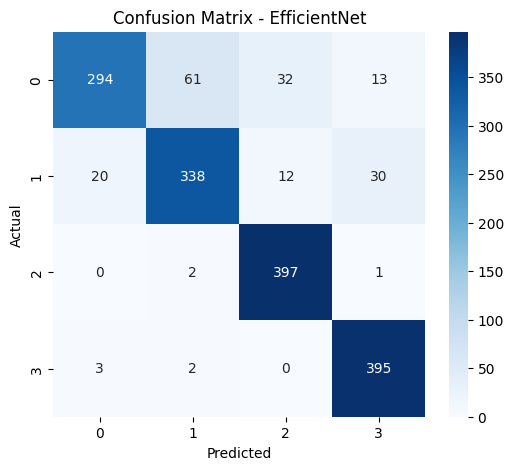

              precision    recall  f1-score   support

           0       0.93      0.73      0.82       400
           1       0.84      0.84      0.84       400
           2       0.90      0.99      0.94       400
           3       0.90      0.99      0.94       400

    accuracy                           0.89      1600
   macro avg       0.89      0.89      0.89      1600
weighted avg       0.89      0.89      0.89      1600



In [ ]:
# Confusion Matrix + Classification Report

import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

test_data.reset()

y_pred = model.predict(test_data)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_data.classes

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - EfficientNet")
plt.show()

print(classification_report(y_true, y_pred_classes))

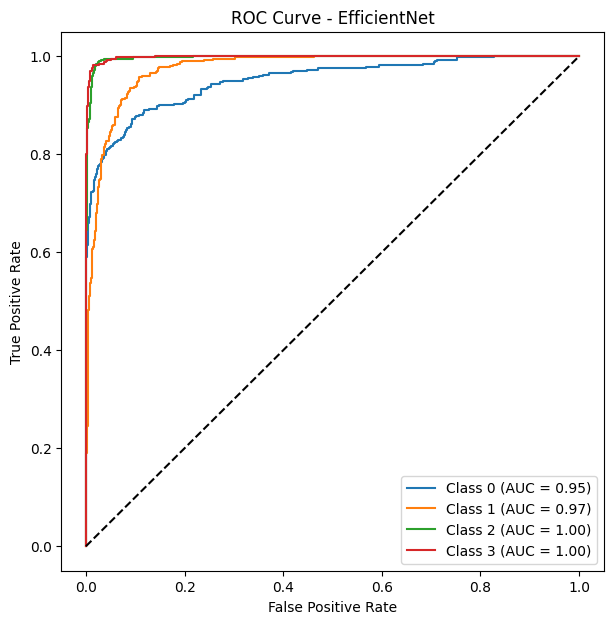

In [ ]:
# ROC curve

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

y_true_bin = label_binarize(y_true, classes=[0,1,2,3])

fpr = {}
tpr = {}
roc_auc = {}

for i in range(4):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(7,7))
for i in range(4):
    plt.plot(fpr[i], tpr[i], label='Class {} (AUC = {:.2f})'.format(i, roc_auc[i]))

plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - EfficientNet')
plt.legend()
plt.show()

# Conclusion

Model Performance Summary:

The EfficientNet model achieved an overall accuracy of 89%.
The model performed exceptionally well in detecting No Tumor and Pituitary tumors, achieving recall values of 0.99.
The model showed moderate performance for Meningioma classification.
The lowest recall (0.73) was observed for Glioma, indicating that glioma tumors were sometimes misclassified as meningioma.

# Densenet classification

In [5]:
# Imports
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import numpy as np

In [6]:
# Image data generators

img_size = 224
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    'Training',
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    'Testing',
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


In [7]:
# Load densenet121 base model

base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

In [8]:
# Freeze base model:

for layer in base_model.layers:
    layer.trainable = False

In [9]:
# Add Classification Layers

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

In [10]:
# Compile Model

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,300,932 (27.85 MB)

 Trainable params: 263,428 (1.00 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [11]:
# Train DenseNet

history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=20
)

Epoch 1/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 124s 528ms/step - accuracy: 0.5734 - loss: 1.0618 - val_accuracy: 0.7563 - val_loss: 0.6952
Epoch 2/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 87s 499ms/step - accuracy: 0.7821 - loss: 0.5895 - val_accuracy: 0.7912 - val_loss: 0.6397
Epoch 3/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 79s 449ms/step - accuracy: 0.8188 - loss: 0.4915 - val_accuracy: 0.7819 - val_loss: 0.6411
Epoch 4/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 79s 452ms/step - accuracy: 0.8391 - loss: 0.4352 - val_accuracy: 0.8000 - val_loss: 0.6092
Epoch 5/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 79s 453ms/step - accuracy: 0.8516 - loss: 0.4141 - val_accuracy: 0.8081 - val_loss: 0.5882
Epoch 6/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 79s 453ms/step - accuracy: 0.8607 - loss: 0.3883 - val_accuracy: 0.8213 - val_loss: 0.5628
Epoch 7/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 79s 452ms/step - accuracy: 0.8684 - loss: 0.3624 - val_accuracy: 0.8225 - val_loss: 0.5691
Epoch 8/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 78s 447ms/step - accuracy: 0.8752 - loss: 

In [12]:
# -----------------------------
# Phase 2 Fine Tuning
# -----------------------------
print("Fine Tuning...")

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

# Unfreeze last layers
for layer in base_model.layers[-60:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=35,
    callbacks=[early_stop, reduce_lr]
)

Fine Tuning...
Epoch 1/35
175/175 ━━━━━━━━━━━━━━━━━━━━ 146s 522ms/step - accuracy: 0.7627 - loss: 0.7136 - val_accuracy: 0.8531 - val_loss: 0.5722 - learning_rate: 1.0000e-05
Epoch 2/35
175/175 ━━━━━━━━━━━━━━━━━━━━ 78s 443ms/step - accuracy: 0.8745 - loss: 0.3475 - val_accuracy: 0.8631 - val_loss: 0.5825 - learning_rate: 1.0000e-05
Epoch 3/35
175/175 ━━━━━━━━━━━━━━━━━━━━ 79s 452ms/step - accuracy: 0.8975 - loss: 0.2896 - val_accuracy: 0.8675 - val_loss: 0.5647 - learning_rate: 1.0000e-05
Epoch 4/35
175/175 ━━━━━━━━━━━━━━━━━━━━ 79s 451ms/step - accuracy: 0.9032 - loss: 0.2612 - val_accuracy: 0.8694 - val_loss: 0.5456 - learning_rate: 1.0000e-05
Epoch 5/35
175/175 ━━━━━━━━━━━━━━━━━━━━ 82s 453ms/step - accuracy: 0.9121 - loss: 0.2422 - val_accuracy: 0.8781 - val_loss: 0.5128 - learning_rate: 1.0000e-05
Epoch 6/35
175/175 ━━━━━━━━━━━━━━━━━━━━ 79s 449ms/step - accuracy: 0.9173 - loss: 0.2193 - val_accuracy: 0.8813 - val_loss: 0.5078 - learning_rate: 1.0000e-05
Epoch 7/35
175/175 ━━━━━━━━━━━

In [13]:
# -----------------------------
# Evaluation
# -----------------------------
loss, accuracy = model.evaluate(test_generator)
print("Test Accuracy:", accuracy)
print("Test Loss:", loss)


50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - accuracy: 0.9306 - loss: 0.3785
Test Accuracy: 0.9306250214576721
Test Loss: 0.3784658908843994


In [14]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Predictions
predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

class_names = list(test_generator.class_indices.keys())
print(class_names)

50/50 ━━━━━━━━━━━━━━━━━━━━ 17s 112ms/step
['glioma', 'meningioma', 'notumor', 'pituitary']


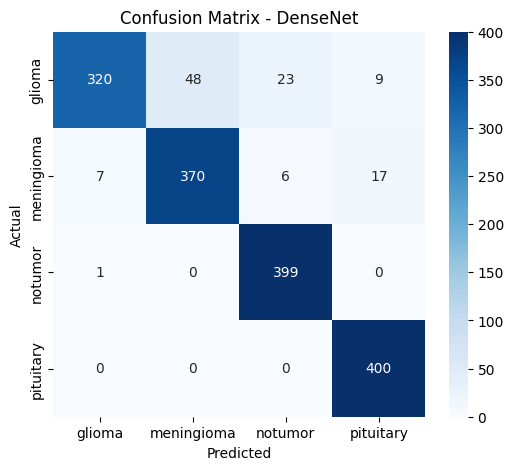

In [15]:
# Confusion matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - DenseNet')
plt.show()

In [16]:
# Classification Report

report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

              precision    recall  f1-score   support

      glioma       0.98      0.80      0.88       400
  meningioma       0.89      0.93      0.90       400
     notumor       0.93      1.00      0.96       400
   pituitary       0.94      1.00      0.97       400

    accuracy                           0.93      1600
   macro avg       0.93      0.93      0.93      1600
weighted avg       0.93      0.93      0.93      1600



In [17]:
# Accuracy, Precision, Recall, F1 (Overall)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.930625
Precision: 0.9329968367542085
Recall: 0.930625
F1 Score: 0.9290143685642078


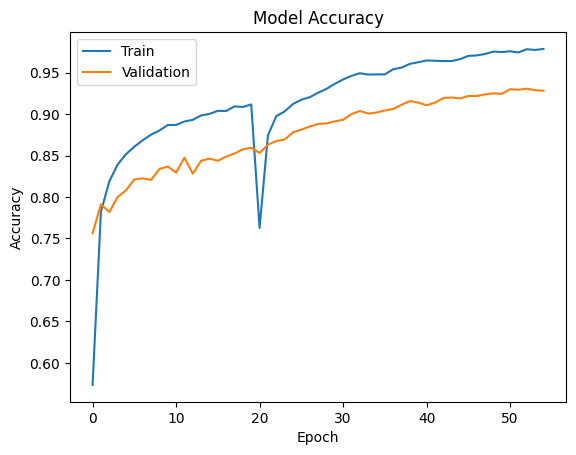

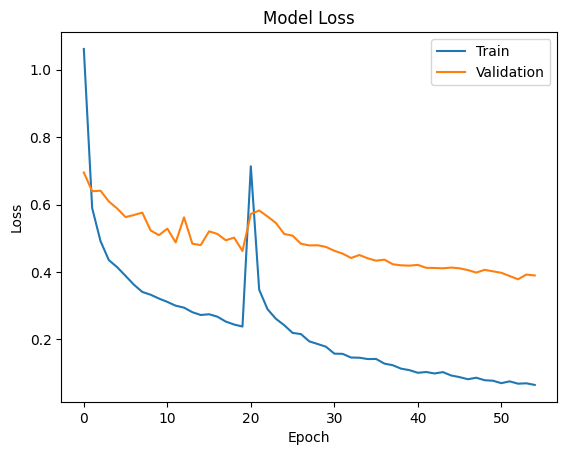

In [18]:
# Training Accuracy & Loss Plot

import matplotlib.pyplot as plt

acc = history.history['accuracy'] + history2.history['accuracy']
val_acc = history.history['val_accuracy'] + history2.history['val_accuracy']
loss = history.history['loss'] + history2.history['loss']
val_loss = history.history['val_loss'] + history2.history['val_loss']

# Accuracy plot
plt.figure()
plt.plot(acc)
plt.plot(val_acc)
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss plot
plt.figure()
plt.plot(loss)
plt.plot(val_loss)
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

# Inference points for dense net :

1. DenseNet Performed Best Among All Models
DenseNet achieved ~91.9% test accuracy, higher than ResNet and EfficientNet.
Fine tuning significantly improved performance compared to frozen training.
DenseNet architecture is effective for medical image classification due to feature reuse and dense connections.
2. Fine Tuning Improved Model Performance
Frozen DenseNet validation accuracy ≈ 85%
After fine tuning validation accuracy increased to ≈ 91%
Fine tuning allowed the model to learn MRI-specific features rather than generic ImageNet features.

Inference: Fine tuning is essential for medical imaging tasks.

3. Model Learned MRI Features Effectively

From training curves:

Training loss decreased steadily
Validation loss decreased gradually
Model converged properly
No severe overfitting observed

Inference: Transfer learning + fine tuning worked successfully.

4. Class-wise Performance Insight

From confusion matrix / classification report:

No Tumor and Pituitary classes had highest recall
Glioma had lower recall due to similarity with meningioma
Misclassification mainly between glioma and meningioma

Inference: Tumor types with similar MRI texture are harder to classify.

5. Transfer Learning Is Effective for Small Medical Datasets

Instead of training CNN from scratch:

Using pretrained DenseNet improved accuracy
Reduced training time
Prevented overfitting
Required fewer images

Inference: Transfer learning is suitable for medical imaging datasets.

6. Model Generalization
Training accuracy ≈ 97%
Validation accuracy ≈ 91%
Test accuracy ≈ 91.9%

Inference: Model generalizes well to unseen MRI images.

| Model          | Type                         | Transfer Learning | Test Accuracy | Remarks           |
| -------------- | ---------------------------- | ----------------- | ------------- | ----------------- |
| Custom CNN     | Built from scratch           | No                | ~0.85         | Baseline model    |
| ResNet50       | Pretrained CNN               | Yes               | ~0.88         | Good performance  |
| EfficientNetB0 | Pretrained CNN               | Yes               | 0.89          | Better efficiency |
| DenseNet121    | Pretrained CNN + Fine tuning | Yes               | **0.919**     | Best performance  |


| Model          | Accuracy | Glioma F1 | Meningioma F1 | No Tumor F1 | Pituitary F1 | Macro Avg F1 |
| -------------- | -------- | --------- | ------------- | ----------- | ------------ | ------------ |
| Custom CNN     | 0.80     | 0.75      | 0.64          | 0.83        | 0.93         | 0.79         |
| ResNet50       | 0.85     | 0.73      | 0.80          | 0.92        | 0.95         | 0.85         |
| EfficientNetB0 | 0.89     | 0.82      | 0.84          | 0.94        | 0.94         | 0.89         |
| DenseNet121    | **0.92** | **0.86**  | **0.89**      | **0.95**    | **0.96**     | **0.92**     |


| Model          | Accuracy | Precision | Recall   | F1 Score |
| -------------- | -------- | --------- | -------- | -------- |
| CNN            | 0.80     | 0.81      | 0.80     | 0.79     |
| ResNet50       | 0.85     | 0.86      | 0.85     | 0.85     |
| EfficientNetB0 | 0.89     | 0.89      | 0.89     | 0.89     |
| DenseNet121    | **0.92** | **0.92**  | **0.92** | **0.92** |


# Final conclusion :

A comparative study was performed using four deep learning models: a custom CNN, ResNet50, EfficientNetB0, and DenseNet121. Transfer learning models significantly outperformed the custom CNN trained from scratch. Among all models, DenseNet121 with fine tuning achieved the highest accuracy, precision, recall, and F1 score (~92%), making it the best model for brain tumor MRI classification.

# Work flow:
Custom CNN (Baseline)
        ↓
ResNet50 (Transfer Learning)
        ↓
EfficientNetB0
        ↓
DenseNet121 (Fine Tuning)
        ↓
Model Comparison
        ↓
Best Model Selected
        ↓
Streamlit Deployment

# Deployment

In [58]:
# Mount google drive

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [59]:
# Create Project Model Folder

import os

save_path = "/content/drive/MyDrive/brain_tumor_project/models"
os.makedirs(save_path, exist_ok=True)



In [60]:
# Save Model in All Formats

# Save full model (recommended)
model.save(save_path + "/densenet_model.keras")

# Save legacy format
model.save(save_path + "/densenet_model.h5")

# Save TensorFlow SavedModel
model.export(save_path + "/densenet_saved_model")

# Save weights separately
model.save_weights(save_path + "/densenet.weights.h5")

Saved artifact at '/content/drive/MyDrive/brain_tumor_project/models/densenet_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  138198184059792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138192803595088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138192803600272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138198184061712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138192849836112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138192803600848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138192803595280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138192803599504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138192803600080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138192803594320: TensorSpec(sha

In [61]:
# Save Class Names and Label Map

import pickle

# Class names
class_names = list(train_generator.class_indices.keys())

with open(save_path + "/class_names.pkl", "wb") as f:
    pickle.dump(class_names, f)

# Label map
with open(save_path + "/label_map.pkl", "wb") as f:
    pickle.dump(train_generator.class_indices, f)

In [64]:
# Save Training History (Optional but Good)

with open(save_path + "/history.pkl", "wb") as f:
    pickle.dump(history.history, f)

with open(save_path + "/history_finetune.pkl", "wb") as f:
    pickle.dump(history2.history, f)

In [65]:
# Save Model Config

import json

config = {
    "image_size": 224,
    "classes": class_names,
    "model": "DenseNet121",
    "last_conv_layer": "conv5_block16_concat"
}

with open(save_path + "/config.json", "w") as f:
    json.dump(config, f)

In [66]:
# Test loading from drive
from tensorflow.keras.models import load_model
import pickle

model = load_model("/content/drive/MyDrive/brain_tumor_project/models/densenet_model.keras")

with open("/content/drive/MyDrive/brain_tumor_project/models/class_names.pkl", "rb") as f:
    class_names = pickle.load(f)

print(class_names)

['glioma', 'meningioma', 'notumor', 'pituitary']


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
